# Sparsity studies

In [1]:
import os
import sys
from pathlib import Path
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
from scipy.optimize import curve_fit
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
# os.environ['CUDA_VISIBLE_DEVICES'] = '7'
jax.config.update('jax_enable_x64', True)

In [2]:
configs = [
    (4, 1),
    (4, 2),
    (4, 3),
    (4, 4),
    (4, 5),
    (4, 6),
    (4, 7),
    (6, 1),
    (6, 2),
    (6, 3),
    (6, 4),
    #(6, 5),
    (8, 1),
    (8, 2),
    (8, 3)
]

# template = '/data/iiyama/2dz2/sparsity_hstack/probs_{}x{}_centercharge.h5'
template = '/data/iiyama/2dz2/sparsity_hstack/eigvecs_{}x{}_centercharge.h5'

### Sparsity at $\lambda \sim 1$

In [3]:
s95s = {}
s2s = {}
s3s = {}
s4s = {}
for config in configs:
    with h5py.File(template.format(*config), 'r', libver='latest') as source:
        lambdas = source['lambdas'][()]
        il = np.searchsorted(lambdas, 0.79)
        # cum_probs = np.cumsum(source[f'probs_{il}'][()])
        probs = np.square(np.abs(source['eigvec'][il]))

    sorted_probs = np.sort(probs)[::-1]
    cum_probs = np.cumsum(sorted_probs)
    s95s[config] = np.searchsorted(cum_probs, 0.95)
    s2s[config] = np.searchsorted(cum_probs, 0.99)
    s3s[config] = np.searchsorted(cum_probs, 0.999)
    s4s[config] = np.searchsorted(cum_probs, 0.9999)

Text(0, 0.5, '$S_p$')

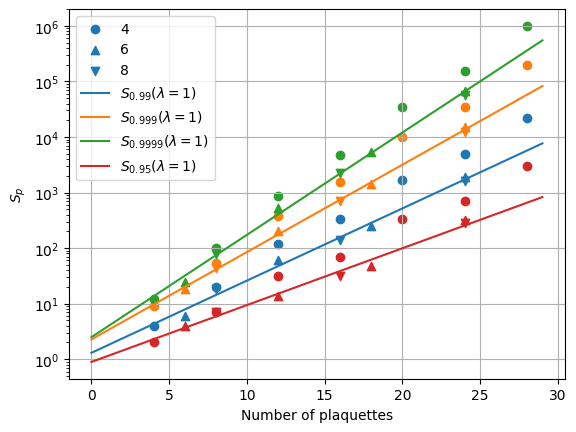

In [4]:
def line(x, a, b):
    return x * a + b

configs_4 = [config for config in configs if config[0] == 4]
configs_6 = [config for config in configs if config[0] == 6]
configs_8 = [config for config in configs if config[0] == 8]
configs_fit = configs_6 + configs_8
nplaq_fit = np.array([np.prod(config) for config in configs_fit])
s95_fit = np.array([s95s[config] for config in configs_fit])
s2_fit = np.array([s2s[config] for config in configs_fit])
s3_fit = np.array([s3s[config] for config in configs_fit])
s4_fit = np.array([s4s[config] for config in configs_fit])

popt95, _ = curve_fit(line, nplaq_fit, np.log(s95_fit), (2. / 12., 0.))
popt2, _ = curve_fit(line, nplaq_fit, np.log(s2_fit), (2. / 12., 0.))
popt3, _ = curve_fit(line, nplaq_fit, np.log(s3_fit), (2. / 12., 0.))
popt4, _ = curve_fit(line, nplaq_fit, np.log(s4_fit), (2. / 12., 0.))
xfine = np.arange(30)

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

entries = {}
for cseries, marker in zip([configs_4, configs_6, configs_8], ['o', '^', 'v']):
    rows = cseries[0][0]
    nplaqs = np.array([np.prod(config) for config in cseries])
    entries[(rows, 99)] = plt.scatter(nplaqs, [s2s[config] for config in cseries], marker=marker,
                                      facecolor=colors[0], edgecolor=colors[0])
    entries[(rows, 999)] = plt.scatter(nplaqs, [s3s[config] for config in cseries], marker=marker,
                                       facecolor=colors[1], edgecolor=colors[1])
    entries[(rows, 9999)] = plt.scatter(nplaqs, [s4s[config] for config in cseries], marker=marker,
                                        facecolor=colors[2], edgecolor=colors[2])
    entries[(rows, 95)] = plt.scatter(nplaqs, [s95s[config] for config in cseries], marker=marker,
                                      facecolor=colors[3], edgecolor=colors[3])
line2, = plt.plot(xfine, np.exp(line(xfine, *popt2)))
line3, = plt.plot(xfine, np.exp(line(xfine, *popt3)))
line4, = plt.plot(xfine, np.exp(line(xfine, *popt4)))
line95, = plt.plot(xfine, np.exp(line(xfine, *popt95)))
plt.legend(
    [entries[(4, 99)], entries[(6, 99)], entries[(8, 99)], line2, line3, line4, line95],
    ['4', '6', '8', r'$S_{0.99}(\lambda=1)$', r'$S_{0.999}(\lambda=1)$', r'$S_{0.9999}(\lambda=1)$', r'$S_{0.95}(\lambda=1)$']
)
# plt.xticks(xfine)
plt.yscale('log')
plt.grid()
plt.xlabel('Number of plaquettes')
plt.ylabel('$S_p$')

In [5]:
np.exp(line(64, *popt95))

np.float64(3154055.0689399713)

In [ ]:
config = (8, 3)
with h5py.File(template.format(*config), 'r', libver='latest') as source:
    lambdas = source['lambdas'][()]
    il = np.searchsorted(lambdas, 0.79)
    # cum_probs = np.cumsum(source[f'probs_{il}'][()])
    probs = np.square(np.abs(source['eigvec'][il]))


In [8]:
line(64, *popt2_8)

np.float64(10.036832173722562)

### Sparsity at $\lambda = 0.6$

In [9]:
nplaqs = {}
s2s = {}
s3s = {}
s4s = {}
for rows, confs in configs.items():
    nplaqs[rows] = np.empty(len(confs), dtype=int)
    s2s[rows] = np.empty_like(nplaqs[rows], dtype=float)
    s3s[rows] = np.empty_like(s2s[rows])
    s4s[rows] = np.empty_like(s2s[rows])
    for iconf, config in enumerate(confs):
        lattice = TriangularZ2Lattice(config)
        nplaq = lattice.num_plaquettes
        nplaqs[rows][iconf] = nplaq
        filename = template.format(rows, iconf + 1)
        with h5py.File(filename, libver='latest') as source:
            lambdas = source['lambdas'][()]
            il1 = np.searchsorted(lambdas, 0.59)
            eigvec = source['eigvec'][il1]
        probs = np.square(np.abs(eigvec))
        sorted_probs = np.sort(probs)[::-1]
        cum_probs = np.cumsum(sorted_probs)
        s2s[rows][iconf] = np.searchsorted(cum_probs, 0.99)
        s3s[rows][iconf] = np.searchsorted(cum_probs, 0.999)
        s4s[rows][iconf] = np.searchsorted(cum_probs, 0.9999)

Text(0, 0.5, '$S_p$')

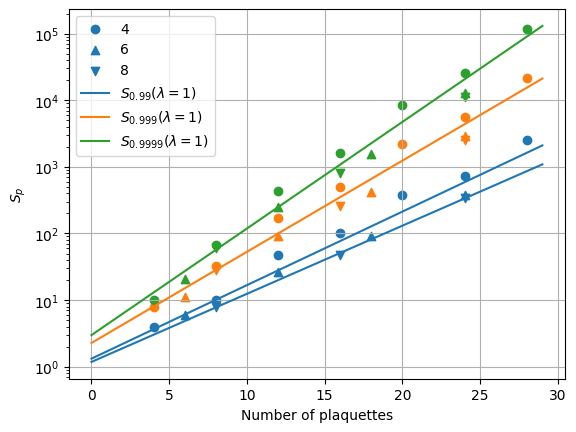

In [11]:
def line(x, a, b):
    return x * a + b

nplaqs_all = np.concatenate(list(nplaqs.values()))
s2s_all = np.concatenate(list(s2s.values()))
s3s_all = np.concatenate(list(s3s.values()))
s4s_all = np.concatenate(list(s4s.values()))

popt2, _ = curve_fit(line, nplaqs_all, np.log10(s2s_all), (2. / 12., 0.))
popt3, _ = curve_fit(line, nplaqs_all, np.log10(s3s_all), (2. / 12., 0.))
popt4, _ = curve_fit(line, nplaqs_all, np.log10(s4s_all), (2. / 12., 0.))
popt2_8, _ = curve_fit(line, nplaqs[8], np.log10(s2s[8]), (2. / 12., 0.))
xfine = np.arange(30)

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

entries = {}
for rows, marker in zip([4, 6, 8], ['o', '^', 'v']):
    entries[(rows, 0)] = plt.scatter(nplaqs[rows], s2s[rows], marker=marker, facecolor=colors[0], edgecolor=colors[0])
    entries[(rows, 1)] = plt.scatter(nplaqs[rows], s3s[rows], marker=marker, facecolor=colors[1], edgecolor=colors[1])
    entries[(rows, 2)] = plt.scatter(nplaqs[rows], s4s[rows], marker=marker, facecolor=colors[2], edgecolor=colors[2])
line2, = plt.plot(xfine, np.power(10., line(xfine, *popt2)), color=colors[0])
line3, = plt.plot(xfine, np.power(10., line(xfine, *popt3)), color=colors[1])
line4, = plt.plot(xfine, np.power(10., line(xfine, *popt4)), color=colors[2])
plt.plot(xfine, np.power(10., line(xfine, *popt2_8)))
plt.legend(
    [entries[(4, 0)], entries[(6, 0)], entries[(8, 0)], line2, line3, line4],
    ['4', '6', '8', r'$S_{0.99}(\lambda=1)$', r'$S_{0.999}(\lambda=1)$', r'$S_{0.9999}(\lambda=1)$']
)
# plt.xticks(xfine)
plt.yscale('log')
plt.grid()
plt.xlabel('Number of plaquettes')
plt.ylabel('$S_p$')

In [12]:
line(64, *popt2_8)

np.float64(6.615760777181722)

### Sparsity of the 8x3 lattice as a function of $\lambda$

In [8]:
lattice_size = (6, 3)

with h5py.File(template.format(*lattice_size), libver='latest') as source:
    eigvec = source['eigvec'][()]
    lambdas = source['lambdas'][()]

probs = np.square(np.abs(eigvec))
sorted_probs = np.sort(probs, axis=1)[:, ::-1]
cum_probs = np.cumsum(sorted_probs, axis=1)
sparsity2 = np.empty(probs.shape[0], dtype=int)
sparsity3 = np.empty(probs.shape[0], dtype=int)
sparsity4 = np.empty(probs.shape[0], dtype=int)
for ilmd, cumul in enumerate(cum_probs):
    sparsity2[ilmd] = np.searchsorted(cumul, 0.99)
    sparsity3[ilmd] = np.searchsorted(cumul, 0.999)
    sparsity4[ilmd] = np.searchsorted(cumul, 0.9999)

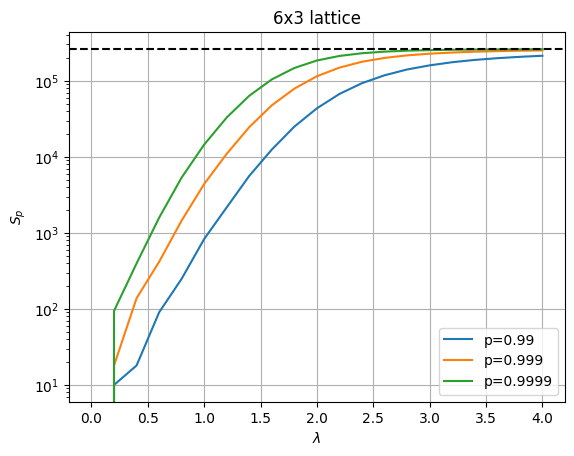

In [9]:
plt.plot(lambdas, sparsity2, label='p=0.99')
plt.plot(lambdas, sparsity3, label='p=0.999')
plt.plot(lambdas, sparsity4, label='p=0.9999')
plt.axhline(probs.shape[1], color='k', linestyle='--')
plt.xlabel(r'$\lambda$')
plt.ylabel('$S_p$')
# plt.ylim(0., 5.e+5)
plt.yscale('log')
plt.title('{}x{} lattice'.format(*lattice_size))
plt.grid()
plt.legend();

## What kind of states are dominant at lambda = 1?

In [10]:
lattice_size = (4, 7)
plaquette_energy = 1.
nplaq = int(np.prod(lattice_size))

with h5py.File(template.format(*lattice_size), libver='latest') as source:
    lambdas = source['lambdas'][()]
    ilmd1 = np.searchsorted(lambdas, plaquette_energy)
    eigvec = source['eigvec'][ilmd1]

probs = np.square(np.abs(eigvec))
sort_idx = np.argsort(probs)[::-1]
sorted_probs = np.sort(probs)[::-1]
cumul = np.cumsum(sorted_probs)

log_residual = np.linspace(0., np.log(0.0001), 50)
coverages = 1. - np.exp(log_residual)
shares = np.zeros(coverages.shape + (nplaq + 1,))
for iquot, coverage in enumerate(coverages):
    idx = np.searchsorted(cumul, coverage)
    if idx == 0:
        continue
    nexc = np.sum((sort_idx[:idx, None] >> np.arange(nplaq)[::-1]) % 2, axis=1)
    mat = np.zeros((idx, nplaq + 1))
    mat[np.arange(idx), nexc] = sorted_probs[:idx]
    shares[iquot] = np.sum(mat, axis=0)

cumshares = np.cumsum(shares, axis=1)

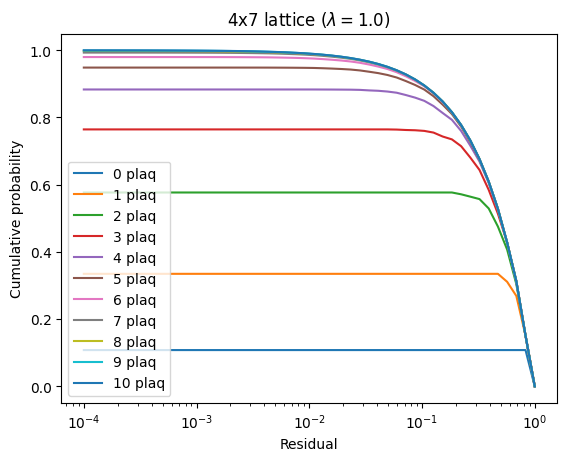

In [11]:
plt.plot(1. - coverages, cumshares[:, :11], label=[f'{n} plaq' for n in range(11)])
plt.xlabel('Residual')
plt.ylabel('Cumulative probability')
plt.title(rf'{lattice_size[0]}x{lattice_size[1]} lattice ($\lambda = {plaquette_energy}$)')
plt.legend()
plt.xscale('log')

## How does sparsity relate to energy error?

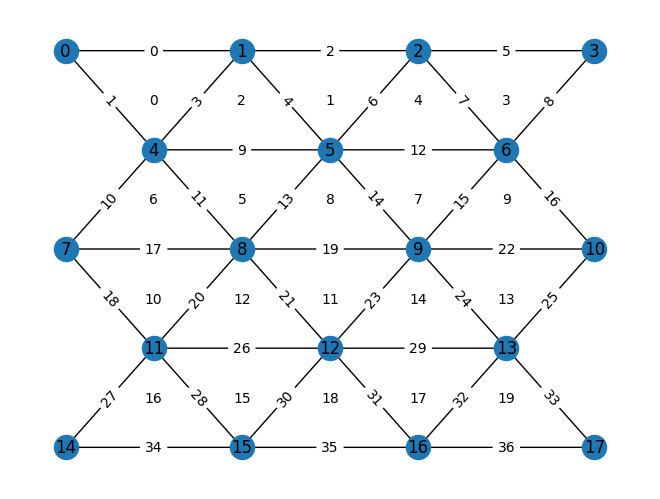

In [9]:
rows, cols = 4, 5

config = configs[rows][cols - 1]
lattice = TriangularZ2Lattice(config)
lattice.draw_graph();


In [12]:
nplaq = lattice.num_plaquettes
filename = template.format(rows, cols)
with h5py.File(filename, libver='latest') as source:
    lambdas = source['lambdas'][()]
    il1 = np.searchsorted(lambdas, 1.)
    eigvec = source['eigvec'][il1]
probs = np.square(np.abs(eigvec))
sorted_probs = np.sort(probs)[::-1]
cum_probs = np.cumsum(sorted_probs)
q3 = np.searchsorted(cum_probs, 0.999)

In [13]:
q3

np.int64(34435)

In [16]:
sorted_states = ((np.argsort(probs)[::-1][:, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)

In [19]:
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][excited_links[rows][cols - 1]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
hamiltonian = dual_lattice.make_hamiltonian(1.)

In [28]:
result = sqd(hamiltonian, sorted_states[:q3])

INFO:skqd_z2lgt.sqd:2.855507 seconds to sort 34435 bitstrings
INFO:skqd_z2lgt.sqd:9.287762 seconds to diagonalize


In [29]:
result

(-35.96433058370595,
 array([4.64751666e-01+0.j, 7.62689282e-02+0.j, 7.73291946e-02+0.j, ...,
        7.95330252e-05+0.j, 7.95330318e-05+0.j, 1.43334092e-04+0.j],
       shape=(34435,)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 1, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(34435, 20), dtype=uint8),
 <Compressed Sparse Row sparse array of dtype 'complex128'
 	with 400587 stored elements and shape (34435, 34435)>)

In [27]:
with h5py.File(filename, libver='latest') as source:
    print(source['eigval'][()])

[-31.         -31.21228103 -31.83848859 -32.85644914 -34.24439814
 -35.97911584 -38.03064472 -40.36530504 -42.95070025 -45.75643368
 -48.75297574 -51.91144224 -55.20454259 -58.60782417 -62.10046181
 -65.66539211 -69.28897403 -72.96043891 -76.67131721 -80.41493295
 -84.18599306]


### Number of plaquettes and mean probability

In [3]:
rows, cols = 4, 5

config = configs[rows][cols - 1]
lattice = TriangularZ2Lattice(config)

nplaq = lattice.num_plaquettes
filename = template.format(rows, cols)
with h5py.File(filename, libver='latest') as source:
    lambdas = source['lambdas'][()]
    eigvecs = source['eigvec'][()]
probs = np.square(np.abs(eigvecs))

In [4]:
excitations = np.bitwise_count(np.arange(2 ** nplaq))
excitation_probs = [np.sort(probs[:, excitations == n]) for n in range(nplaq + 1)]
minima = np.stack([ep[:, 0] for ep in excitation_probs], axis=1)
maxima = np.stack([ep[:, -1] for ep in excitation_probs], axis=1)
median = np.stack([np.quantile(ep, 0.5, axis=1) for ep in excitation_probs], axis=1)
mean = np.stack([np.mean(ep, axis=1) for ep in excitation_probs], axis=1)

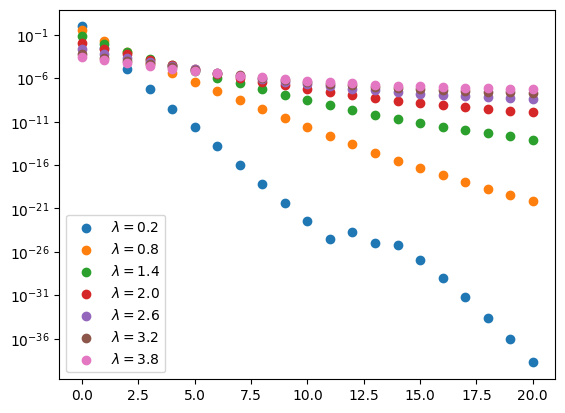

In [5]:
for il in range(1, nplaq, 3):
    plt.scatter(np.arange(nplaq + 1), mean[il], label=fr'$\lambda={lambdas[il]:.1f}$')
plt.yscale('log')
plt.legend();

In [6]:
def line(x, a, b):
    return a * x + b

popt, _ = curve_fit(line, np.arange(12), np.log(mean[1, :12]), p0=(np.log(lambdas[1]), 0.))

In [7]:
popt

array([-5.10526939, -0.9079599 ])

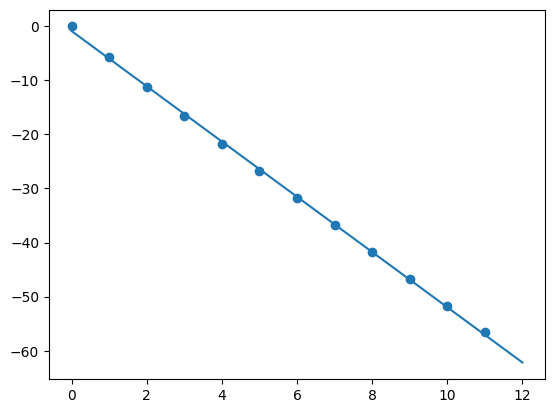

In [8]:
plt.scatter(np.arange(12), np.log(mean[1, :12]))
plt.plot(np.linspace(0., 12., 100), line(np.linspace(0., 12., 100), *popt))

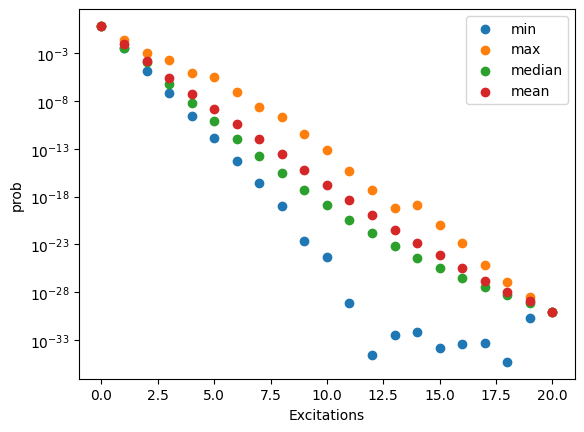

In [11]:
il = 2
x = np.arange(nplaq + 1)
plt.scatter(x, minima[il], label='min')
plt.scatter(x, maxima[il], label='max')
plt.scatter(x, median[il], label='median')
plt.scatter(x, mean[il], label='mean')
plt.yscale('log')
plt.xlabel('Excitations')
plt.ylabel('prob')
plt.legend();

### Range of probabilities within each plaquette-number sector

In [3]:
rows, cols = 4, 5

config = configs[rows][cols - 1]
lattice = TriangularZ2Lattice(config)

nplaq = lattice.num_plaquettes
filename = template.format(rows, cols)
with h5py.File(filename, libver='latest') as source:
    lambdas = source['lambdas'][()]
    eigvecs = source['eigvec'][()]
probs = np.square(np.abs(eigvecs))

In [ ]:
excitations = np.bitwise_count(np.arange(2 ** nplaq))
exc_probs = []

[np.float64(17.0), np.float64(25.0), np.float64(33.0), np.float64(821.0)]


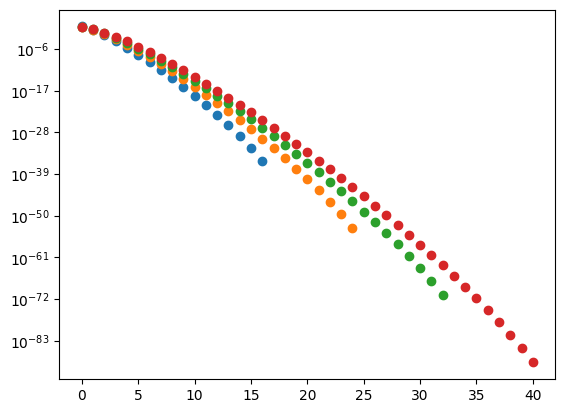

In [31]:
from scipy.special import comb
gamma = np.exp(-5.1)
epsilon = 0.999
ls = []
for largen in [16, 24, 32, 40]:
    smalln = np.arange(largen + 1)
    pvalues = np.power(gamma, smalln) / np.power(1. + gamma, largen) * comb(largen, smalln)
    plt.scatter(smalln, pvalues)
    cump = np.cumsum(pvalues)
    qe = np.searchsorted(cump, epsilon)
    ls.append(np.sum(comb(largen, smalln[:qe])))

plt.yscale('log')
print(ls)


### $|\gamma_0|^2$

In [ ]:
nplaqs = []
gamma_0s = []
for rows in [4, 6, 8]:
    for iconfig in range(len(configs[rows])):
        nplaqs.append(rows * (iconfig + 1))
        filename = template.format(rows, iconfig + 1)
        with h5py.File(filename, 'r', libver='latest') as source:
            gamma_0s.append(np.square(np.abs(source['eigvec'][:, 0])))

nplaqs = np.array(nplaqs)
gamma_0s = np.array(gamma_0s)

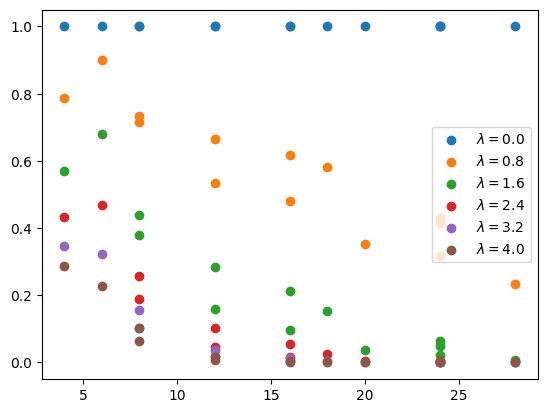

In [14]:
lambdas = np.linspace(0., 4., 21)
for ilmd in range(0, lambdas.shape[0], 4):
    plt.scatter(nplaqs, gamma_0s[:, ilmd], label=fr'$\lambda={lambdas[ilmd]:.1f}$')

plt.legend();

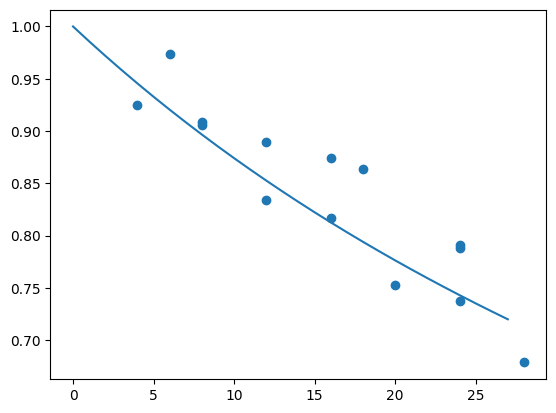

In [23]:
plt.scatter(nplaqs, gamma_0s[:, 2])
plt.plot(np.arange(28), 1. / (1. + np.square(0.4 * 0.3) * np.arange(28)))

In [24]:
1 / (1 + (0.4 * 0.3) ** 2 * 64)

0.5203996669442131

In [17]:
for rows in [4, 6, 8]:
    for iconfig in range(len(configs[rows])):
        filename = template.format(rows, iconfig + 1)
        with h5py.File(filename, 'r', libver='latest') as source:
            print(rows, iconfig + 1, source['eigval'][2:4])

4 1 [-9.20459623 -9.44089163]
4 2 [-15.31364115 -15.69089363]
4 3 [-20.52145396 -21.1475909 ]
4 4 [-26.6306286  -27.39887381]
4 5 [-31.83848859 -32.85644914]
4 6 [-37.94766632 -39.1078479 ]
4 7 [-43.1555278  -44.56552985]
6 1 [-16.15952597 -16.35760118]
6 2 [-23.42030486 -23.93085994]
6 3 [-33.58278371 -34.3016967 ]
6 4 [-40.84419772 -41.88006091]
8 1 [-19.31102382 -19.6796694 ]
8 2 [-31.52696856 -32.17082602]
8 3 [-42.84168674 -43.86874259]
